# Insurance Fraud Detection - Autoencoder Pipeline

This notebook combines feature engineering and autoencoder training into a single pipeline.

**Key Improvements:**
- Removed target encoding (replaced with frequency encoding)
- Removed outlier clipping to preserve anomalies
- Reduced feature count through simplification
- Optimized autoencoder architecture with smaller bottleneck
- Reduced noise injection and improved activations

## Setup and Imports

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix, 
                             roc_curve, precision_recall_curve, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

## Part 1: Feature Engineering

### Load Data

In [48]:
df = pd.read_csv('train.csv')
print(f"\nLoaded dataset: {df.shape}")

# Separate features and target
target_col = 'FraudFound'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Features: {X.shape[1]}")
print(f"Fraud cases: {y.sum()} ({y.mean()*100:.2f}%)")
print(f"Normal cases: {(y==0).sum()} ({(y==0).mean()*100:.2f}%)")


Loaded dataset: (12336, 33)
Features: 32
Fraud cases: 738 (5.98%)
Normal cases: 11598 (94.02%)


### Handle Missing Values

In [49]:
print("HANDLE MISSING VALUES")

X_engineered = X.copy()

# Replace '0' placeholders with NaN
X_engineered['DayOfWeekClaimed'] = X_engineered['DayOfWeekClaimed'].replace('0', np.nan)
X_engineered['MonthClaimed'] = X_engineered['MonthClaimed'].replace('0', np.nan)

# Only 1 missing value each - too rare to create indicators
# Just fill with mode
print("Missing values: 1 in DayOfWeekClaimed, 1 in MonthClaimed")
print("Filling with mode (too rare for indicator features)")

HANDLE MISSING VALUES
Missing values: 1 in DayOfWeekClaimed, 1 in MonthClaimed
Filling with mode (too rare for indicator features)


### Drop Low-Signal Features

In [50]:
print("DROP LOW-SIGNAL FEATURES")

cols_to_drop = [
    'PolicyNumber',  # All unique - no pattern
]

print("Dropping:")
print(f"  - PolicyNumber (all unique values)")

X_engineered = X_engineered.drop(columns=cols_to_drop)
print(f"\nRemaining features: {X_engineered.shape[1]}")

DROP LOW-SIGNAL FEATURES
Dropping:
  - PolicyNumber (all unique values)

Remaining features: 31


### Numeric Feature Engineering

In [51]:
print("NUMERIC FEATURE ENGINEERING")

# 1. VehiclePrice - Ordinal encoding
vehicle_price_map = {
    'less than 20,000': 1,
    '20,000 to 29,000': 2,
    '30,000 to 39,000': 3,
    '40,000 to 59,000': 4,
    '60,000 to 69,000': 5,
    'more than 69,000': 6
}
X_engineered['VehiclePrice'] = X_engineered['VehiclePrice'].map(vehicle_price_map)

# 2. Days:Policy-Accident - Since 98.9% are "more than 30", use ordinal
days_policy_accident_map = {
    'none': 0,
    '1 to 7': 1,
    '8 to 15': 2,
    '15 to 30': 3,
    'more than 30': 4
}
X_engineered['DaysPolicyAccident'] = X_engineered['Days:Policy-Accident'].map(days_policy_accident_map)

# 3. Days:Policy-Claim - Ordinal
days_policy_claim_map = {
    'none': 0,
    '1 to 7': 1,
    '8 to 15': 2,
    '15 to 30': 3,
    'more than 30': 4
}
X_engineered['DaysPolicyClaim'] = X_engineered['Days:Policy-Claim'].map(days_policy_claim_map)

# 4. PastNumberOfClaims - Ordinal
past_claims_map = {
    'none': 0,
    '1': 1,
    '2 to 4': 2,
    'more than 4': 3
}
X_engineered['PastNumberOfClaims'] = X_engineered['PastNumberOfClaims'].map(past_claims_map)

# 5. AgeOfVehicle - Parse to numeric
def parse_vehicle_age(age_str):
    if pd.isna(age_str):
        return np.nan
    age_str = str(age_str).lower().strip()
    if 'new' in age_str:
        return 0
    if 'more than 7' in age_str or age_str == 'more than 7':
        return 8
    import re
    match = re.search(r'(\d+)', age_str)
    if match:
        return int(match.group(1))
    return np.nan

X_engineered['AgeOfVehicle'] = X_engineered['AgeOfVehicle'].apply(parse_vehicle_age)

# 6. AgeOfPolicyHolder - Ordinal with midpoints
age_policyholder_map = {
    '16 to 17': 1,
    '18 to 20': 2,
    '21 to 25': 3,
    '26 to 30': 4,
    '31 to 35': 5,
    '36 to 40': 6,
    '41 to 50': 7,
    '51 to 65': 8,
    'over 65': 9
}
X_engineered['AgeOfPolicyHolder'] = X_engineered['AgeOfPolicyHolder'].map(age_policyholder_map)

# 7. NumberOfSuppliments - Ordinal
suppliments_map = {
    'none': 0,
    '1 to 2': 1,
    '3 to 5': 2,
    'more than 5': 3
}
X_engineered['NumberOfSuppliments'] = X_engineered['NumberOfSuppliments'].map(suppliments_map)

# 8. NumberOfCars - Ordinal
number_cars_map = {
    '1 vehicle': 1,
    '2 vehicles': 2,
    '3 to 4': 3,
    '5 to 8': 4,
    'more than 8': 5
}
X_engineered['NumberOfCars'] = X_engineered['NumberOfCars'].map(number_cars_map)

# 9. AddressChange-Claim - Ordinal
address_change_map = {
    'under 6 months': 1,
    '1 year': 2,
    '2 to 3 years': 3,
    '4 to 8 years': 4,
    'no change': 5
}
X_engineered['AddressChangeClaim'] = X_engineered['AddressChange-Claim'].map(address_change_map)
print(f"  Encoded 1-5")

NUMERIC FEATURE ENGINEERING
  Encoded 1-5


### Temporal Features

In [52]:
print("TEMPORAL FEATURES")

# Month - Keep numeric (1-12)
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
X_engineered['Month'] = X_engineered['Month'].map(month_map)

# MonthClaimed - Fill missing with mode, then encode
print("\nMonthClaimed - Numeric encoding")
mode_month = X_engineered['MonthClaimed'].mode()[0]
X_engineered['MonthClaimed'] = X_engineered['MonthClaimed'].fillna(mode_month)
X_engineered['MonthClaimed'] = X_engineered['MonthClaimed'].map(month_map)
print(f"  Filled missing with mode: {mode_month}, Encoded 1-12")

# DayOfWeek - Keep numeric (1-7)
print("\nDayOfWeek - Numeric encoding")
day_map = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4,
           'Friday': 5, 'Saturday': 6, 'Sunday': 7}
X_engineered['DayOfWeek'] = X_engineered['DayOfWeek'].map(day_map)
print(f"  Encoded 1-7")

# DayOfWeekClaimed - Fill missing with mode, then encode
print("\nDayOfWeekClaimed - Numeric encoding")
mode_day = X_engineered['DayOfWeekClaimed'].mode()[0]
X_engineered['DayOfWeekClaimed'] = X_engineered['DayOfWeekClaimed'].fillna(mode_day)
X_engineered['DayOfWeekClaimed'] = X_engineered['DayOfWeekClaimed'].map(day_map)
print(f"  Filled missing with mode: {mode_day}, Encoded 1-7")

# Year - Normalize to 0-1
print("\nYear - Normalize")
X_engineered['Year'] = (X_engineered['Year'] - X_engineered['Year'].min()) / \
                       (X_engineered['Year'].max() - X_engineered['Year'].min())
print(f"  Normalized to [0, 1]")

TEMPORAL FEATURES

MonthClaimed - Numeric encoding
  Filled missing with mode: Jan, Encoded 1-12

DayOfWeek - Numeric encoding
  Encoded 1-7

DayOfWeekClaimed - Numeric encoding
  Filled missing with mode: Monday, Encoded 1-7

Year - Normalize
  Normalized to [0, 1]


### Binary Encoding

In [53]:
print("BINARY ENCODING")

binary_features = {
    'Sex': {'Female': 0, 'Male': 1},
    'AccidentArea': {'Rural': 0, 'Urban': 1},
    'Fault': {'Third Party': 0, 'Policy Holder': 1},
    'PoliceReportFiled': {'No': 0, 'Yes': 1},
    'WitnessPresent': {'No': 0, 'Yes': 1},
    'AgentType': {'Internal': 0, 'External': 1}
}

for col, mapping in binary_features.items():
    X_engineered[col] = X_engineered[col].map(mapping)
    print(f"  {col}: Encoded 0-1")

BINARY ENCODING
  Sex: Encoded 0-1
  AccidentArea: Encoded 0-1
  Fault: Encoded 0-1
  PoliceReportFiled: Encoded 0-1
  WitnessPresent: Encoded 0-1
  AgentType: Encoded 0-1


### Frequency Encoding for High-Cardinality Categoricals

In [54]:
print("FREQUENCY ENCODING FOR HIGH-CARDINALITY CATEGORICALS")

# This is the KEY fix - use frequency encoding instead of target encoding
# Frequency encoding captures category importance without using fraud labels

print("\nUsing FREQUENCY ENCODING (not target encoding)")
print("Frequency = proportion of samples in each category")

# Make - Too many categories (19), use frequency encoding
print("\nMake - Frequency encoding")
make_freq = X_engineered['Make'].value_counts(normalize=True).to_dict()
X_engineered['Make_Freq'] = X_engineered['Make'].map(make_freq)
print(f"  Encoded with frequencies (19 unique makes)")

# MaritalStatus - Simple one-hot (only 4 categories)
print("\nMaritalStatus - One-hot encoding")
marital_dummies = pd.get_dummies(X_engineered['MaritalStatus'], prefix='Marital', drop_first=True)
X_engineered = pd.concat([X_engineered, marital_dummies], axis=1)
print(f"  Created {len(marital_dummies.columns)} dummy features")

# PolicyType - Frequency encoding (9 categories)
print("\nPolicyType - Frequency encoding")
policy_freq = X_engineered['PolicyType'].value_counts(normalize=True).to_dict()
X_engineered['PolicyType_Freq'] = X_engineered['PolicyType'].map(policy_freq)
print(f"  Encoded with frequencies (9 types)")

# VehicleCategory - One-hot (only 3 categories)
print("\nVehicleCategory - One-hot encoding")
vehicle_cat_dummies = pd.get_dummies(X_engineered['VehicleCategory'], prefix='VehCat', drop_first=True)
X_engineered = pd.concat([X_engineered, vehicle_cat_dummies], axis=1)
print(f"  Created {len(vehicle_cat_dummies.columns)} dummy features")

# BasePolicy - One-hot (only 3 categories)
print("\nBasePolicy - One-hot encoding")
base_policy_dummies = pd.get_dummies(X_engineered['BasePolicy'], prefix='BasePolicy', drop_first=True)
X_engineered = pd.concat([X_engineered, base_policy_dummies], axis=1)
print(f"  Created {len(base_policy_dummies.columns)} dummy features")

FREQUENCY ENCODING FOR HIGH-CARDINALITY CATEGORICALS

Using FREQUENCY ENCODING (not target encoding)
Frequency = proportion of samples in each category

Make - Frequency encoding
  Encoded with frequencies (19 unique makes)

MaritalStatus - One-hot encoding
  Created 3 dummy features

PolicyType - Frequency encoding
  Encoded with frequencies (9 types)

VehicleCategory - One-hot encoding
  Created 2 dummy features

BasePolicy - One-hot encoding
  Created 2 dummy features


### Domain-Specific Interaction Features

In [55]:
print("MINIMAL DOMAIN-SPECIFIC INTERACTIONS")

print("\nCreating ONLY high-value interaction features:")
print("(Based on domain knowledge of insurance fraud patterns)")

# High-risk combinations that might indicate fraud
X_engineered['NoPoliceReport_AtFault'] = \
    (X_engineered['PoliceReportFiled'] == 0) & (X_engineered['Fault'] == 1)
X_engineered['NoPoliceReport_AtFault'] = X_engineered['NoPoliceReport_AtFault'].astype(int)
print("  1. NoPoliceReport_AtFault")

X_engineered['NoWitness_NoPoliceReport'] = \
    (X_engineered['WitnessPresent'] == 0) & (X_engineered['PoliceReportFiled'] == 0)
X_engineered['NoWitness_NoPoliceReport'] = X_engineered['NoWitness_NoPoliceReport'].astype(int)
print("  2. NoWitness_NoPoliceReport")

X_engineered['QuickClaim_NoPoliceReport'] = \
    (X_engineered['DaysPolicyClaim'] <= 2) & (X_engineered['PoliceReportFiled'] == 0)
X_engineered['QuickClaim_NoPoliceReport'] = X_engineered['QuickClaim_NoPoliceReport'].astype(int)
print("  3. QuickClaim_NoPoliceReport")

X_engineered['HighSupplements_NoPoliceReport'] = \
    (X_engineered['NumberOfSuppliments'] >= 2) & (X_engineered['PoliceReportFiled'] == 0)
X_engineered['HighSupplements_NoPoliceReport'] = X_engineered['HighSupplements_NoPoliceReport'].astype(int)
print("  4. HighSupplements_NoPoliceReport")

print(f"\nTotal interaction features: 4 (reduced from 25)")

MINIMAL DOMAIN-SPECIFIC INTERACTIONS

Creating ONLY high-value interaction features:
(Based on domain knowledge of insurance fraud patterns)
  1. NoPoliceReport_AtFault
  2. NoWitness_NoPoliceReport
  3. QuickClaim_NoPoliceReport
  4. HighSupplements_NoPoliceReport

Total interaction features: 4 (reduced from 25)


### Drop Original Categorical Columns

In [56]:
cols_to_drop_final = [
    'Days:Policy-Accident', 'Days:Policy-Claim',
    'AddressChange-Claim',
    'Make', 'MaritalStatus', 'PolicyType', 'VehicleCategory', 'BasePolicy'
]

X_engineered = X_engineered.drop(columns=cols_to_drop_final)
print(f"Dropped {len(cols_to_drop_final)} original categorical columns")
print(f"Current features: {X_engineered.shape[1]}")

Dropped 8 original categorical columns
Current features: 39


### Train/Validation/Test Split

In [57]:
print("TRAIN/VALIDATION/TEST SPLIT")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_engineered, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"  Fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Val:   {X_val.shape[0]} samples")
print(f"  Fraud: {y_val.sum()} ({y_val.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape[0]} samples")
print(f"  Fraud: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

TRAIN/VALIDATION/TEST SPLIT

Train: 8635 samples, 39 features
  Fraud: 517 (5.99%)
Val:   1850 samples
  Fraud: 110 (5.95%)
Test:  1851 samples
  Fraud: 111 (6.00%)


### Robust Scaling

In [58]:
print("STEP 10: ROBUST SCALING - NO OUTLIER CLIPPING")
print("Reason: Fraud cases might be outliers - we need to preserve them")

scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaled {X_train_scaled.shape[1]} features using RobustScaler")

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

STEP 10: ROBUST SCALING - NO OUTLIER CLIPPING
Reason: Fraud cases might be outliers - we need to preserve them

Scaled 39 features using RobustScaler


### Prepare Autoencoder Training Data

In [59]:
print("PREPARE AUTOENCODER TRAINING DATA")

# Use only normal cases for training
X_train_normal = X_train_scaled[y_train == 0]

print(f"\nAutoencoder training data:")
print(f"  Normal cases: {X_train_normal.shape[0]} samples")
print(f"  Features: {X_train_normal.shape[1]}")

print(f"\nData ready for autoencoder")
print(f"  Training: {X_train_normal.shape[0]} normal cases")
print(f"  Validation: {X_val_scaled.shape[0]} cases ({y_val.sum()} fraud)")
print(f"  Test: {X_test_scaled.shape[0]} cases ({y_test.sum()} fraud)")

PREPARE AUTOENCODER TRAINING DATA

Autoencoder training data:
  Normal cases: 8118 samples
  Features: 39

Data ready for autoencoder
  Training: 8118 normal cases
  Validation: 1850 cases (110 fraud)
  Test: 1851 cases (111 fraud)


## Part 2: Autoencoder Training

### Setup PyTorch

In [60]:
print("FIXED AUTOENCODER FOR FRAUD DETECTION")
print("Optimized architecture: smaller bottleneck, less noise, LeakyReLU")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

print("PREPARING DATA FOR PYTORCH")

# Convert to numpy for PyTorch
y_val_np = y_val.values
y_test_np = y_test.values

print(f"\nTraining (normal only): {X_train_normal.shape}")
print(f"Validation: {X_val_scaled.shape}")
print(f"  - Fraud: {y_val_np.sum()} ({y_val_np.mean()*100:.2f}%)")
print(f"  - Normal: {(y_val_np==0).sum()} ({(y_val_np==0).mean()*100:.2f}%)")
print(f"Test: {X_test_scaled.shape}")
print(f"  - Fraud: {y_test_np.sum()} ({y_test_np.mean()*100:.2f}%)")
print(f"  - Normal: {(y_test_np==0).sum()} ({(y_test_np==0).mean()*100:.2f}%)")

input_dim = X_train_normal.shape[1]
print(f"\nInput dimension: {input_dim} features")

# Convert to PyTorch tensors
X_train_normal_tensor = torch.FloatTensor(X_train_normal.values).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled.values).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled.values).to(device)

# Create validation set with normal cases only for monitoring training
X_val_normal = X_val_scaled[y_val == 0]
X_val_normal_tensor = torch.FloatTensor(X_val_normal.values).to(device)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_normal_tensor, X_train_normal_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_normal_tensor, X_val_normal_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")

FIXED AUTOENCODER FOR FRAUD DETECTION
Optimized architecture: smaller bottleneck, less noise, LeakyReLU

Using device: cpu
PREPARING DATA FOR PYTORCH

Training (normal only): (8118, 39)
Validation: (1850, 39)
  - Fraud: 110 (5.95%)
  - Normal: 1740 (94.05%)
Test: (1851, 39)
  - Fraud: 111 (6.00%)
  - Normal: 1740 (94.00%)

Input dimension: 39 features

Batch size: 64
Training batches: 127


### Define Autoencoder Architecture

In [61]:
print("BUILDING AUTOENCODER")

# KEY FIX: Smaller bottleneck for stronger compression
# Target: 7-9% of input dimension for aggressive compression
encoding_dim = max(4, int(input_dim * 0.08))  # 8% of input, minimum 4

print(f"\nArchitecture Design:")
print(f"  SMALLER BOTTLENECK: {encoding_dim} dimensions ({encoding_dim/input_dim*100:.1f}% compression)")
print(f"  Previous: 10 dims (11.6% compression)")
print(f"  Activation: LeakyReLU (avoids dead neurons)")
print(f"  Regularization: Moderate dropout + BatchNorm")
print(f"  Architecture: {input_dim} → 32 → 16 → {encoding_dim} → 16 → 32 → {input_dim}")

class ImprovedAutoencoder(nn.Module):
    """
    Optimized Autoencoder for Anomaly Detection
    
    Key improvements:
    - SMALLER bottleneck (7-9% compression instead of 11.6%)
    - LeakyReLU to prevent dead neurons
    - Reduced regularization (less BatchNorm)
    - Simpler architecture
    - Lower noise during training
    """
    
    def __init__(self, input_dim, encoding_dim, dropout_rate=0.2):
        super(ImprovedAutoencoder, self).__init__()
        
        # Encoder: Aggressive compression
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),
            
            nn.Linear(16, encoding_dim),
            nn.Tanh()  # Bounded representation
        )
        
        # Decoder: Symmetric expansion
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),
            
            nn.Linear(16, 32),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x, add_noise=False, noise_factor=0.05):
        """
        Forward pass with optional noise injection
        
        Args:
            x: Input tensor
            add_noise: If True, add Gaussian noise
            noise_factor: Standard deviation of noise (reduced from 0.1 to 0.05)
        """
        if add_noise and self.training:
            noise = torch.randn_like(x) * noise_factor
            x = x + noise
        
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        """Get the compressed representation"""
        return self.encoder(x)

# Initialize model
model = ImprovedAutoencoder(input_dim, encoding_dim, dropout_rate=0.2).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel initialized:")
print(f"  - Encoder layers: 3")
print(f"  - Decoder layers: 3")
print(f"  - Dropout rate: 0.2 (reduced from 0.3)")
print(f"  - Total parameters: {total_params:,}")

BUILDING AUTOENCODER

Architecture Design:
  SMALLER BOTTLENECK: 4 dimensions (10.3% compression)
  Previous: 10 dims (11.6% compression)
  Activation: LeakyReLU (avoids dead neurons)
  Regularization: Moderate dropout + BatchNorm
  Architecture: 39 → 32 → 16 → 4 → 16 → 32 → 39

Model initialized:
  - Encoder layers: 3
  - Decoder layers: 3
  - Dropout rate: 0.2 (reduced from 0.3)
  - Total parameters: 3,915


### Training Setup

In [62]:
print("TRAINING SETUP")

# Loss function
criterion = nn.MSELoss()

# Optimizer: AdamW with weight decay
optimizer = optim.AdamW(
    model.parameters(), 
    lr=0.001, 
    weight_decay=1e-5,
    betas=(0.9, 0.999)
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=10, 
    min_lr=1e-6,
)

print(f"\nTraining configuration:")
print(f"  - Loss: MSE")
print(f"  - Optimizer: AdamW (lr=0.001, weight_decay=1e-5)")
print(f"  - Scheduler: ReduceLROnPlateau (patience=10)")
print(f"  - Noise injection: REDUCED to std=0.05 (was 0.1)")
print(f"  - Gradient clipping: Enabled (max_norm=1.0)")


TRAINING SETUP

Training configuration:
  - Loss: MSE
  - Optimizer: AdamW (lr=0.001, weight_decay=1e-5)
  - Scheduler: ReduceLROnPlateau (patience=10)
  - Noise injection: REDUCED to std=0.05 (was 0.1)
  - Gradient clipping: Enabled (max_norm=1.0)


### Train the Autoencoder

In [63]:
print("TRAINING AUTOENCODER")

num_epochs = 150
patience = 20
noise_factor = 0.05  # REDUCED from 0.1

print(f"\nTraining parameters:")
print(f"  - Epochs: {num_epochs} (with early stopping)")
print(f"  - Early stopping patience: {patience}")
print(f"  - Training on: {len(X_train_normal)} normal cases only")
print(f"  - Validation on: {len(X_val_normal)} normal cases")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

print(f"\nStarting training...\n")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass with noise injection
        outputs = model(batch_X, add_noise=True, noise_factor=noise_factor)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X, add_noise=False)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch
        # Save best model state
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter}/{patience}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.6f} at epoch {best_epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)

print(f"TRAINING COMPLETE")
print(f"\nBest model from epoch {best_epoch+1}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Final train loss: {train_losses[best_epoch]:.6f}")

TRAINING AUTOENCODER

Training parameters:
  - Epochs: 150 (with early stopping)
  - Early stopping patience: 20
  - Training on: 8118 normal cases only
  - Validation on: 1740 normal cases

Starting training...

Epoch [ 10/150] | Train Loss: 6.929090 | Val Loss: 9.990780 | LR: 0.001000 | Patience: 1/20
Epoch [ 20/150] | Train Loss: 5.049272 | Val Loss: 14.857939 | LR: 0.001000 | Patience: 9/20
Epoch [ 30/150] | Train Loss: 4.555041 | Val Loss: 8.860912 | LR: 0.000500 | Patience: 19/20

Early stopping triggered at epoch 31
Best validation loss: 5.453339 at epoch 11
TRAINING COMPLETE

Best model from epoch 11
Best validation loss: 5.453339
Final train loss: 6.568413


### Calculate Reconstruction Errors

In [64]:
print("CALCULATING RECONSTRUCTION ERRORS")

model.eval()

# Calculate errors for all sets
with torch.no_grad():
    # Training errors (normal only)
    train_reconstructed = model(X_train_normal_tensor)
    train_errors = torch.mean((X_train_normal_tensor - train_reconstructed) ** 2, dim=1).cpu().numpy()
    
    # Validation errors
    val_reconstructed = model(X_val_tensor)
    val_errors = torch.mean((X_val_tensor - val_reconstructed) ** 2, dim=1).cpu().numpy()
    
    # Test errors
    test_reconstructed = model(X_test_tensor)
    test_errors = torch.mean((X_test_tensor - test_reconstructed) ** 2, dim=1).cpu().numpy()

# Split test errors by class
test_errors_normal = test_errors[y_test_np == 0]
test_errors_fraud = test_errors[y_test_np == 1]

# Split validation errors by class
val_errors_normal = val_errors[y_val_np == 0]
val_errors_fraud = val_errors[y_val_np == 1]

print(f"\nReconstruction Error Statistics:")
print(f"\nTraining (Normal only):")
print(f"  Mean: {train_errors.mean():.6f}")
print(f"  Std:  {train_errors.std():.6f}")
print(f"  Min:  {train_errors.min():.6f}")
print(f"  Max:  {train_errors.max():.6f}")

print(f"\nValidation Normal:")
print(f"  Mean: {val_errors_normal.mean():.6f}")
print(f"  Std:  {val_errors_normal.std():.6f}")

print(f"\nValidation Fraud:")
print(f"  Mean: {val_errors_fraud.mean():.6f}")
print(f"  Std:  {val_errors_fraud.std():.6f}")

print(f"\nTest Normal:")
print(f"  Mean: {test_errors_normal.mean():.6f}")
print(f"  Std:  {test_errors_normal.std():.6f}")

print(f"\nTest Fraud:")
print(f"  Mean: {test_errors_fraud.mean():.6f}")
print(f"  Std:  {test_errors_fraud.std():.6f}")

# Calculate separation ratio
separation_ratio = test_errors_fraud.mean() / test_errors_normal.mean()

print(f"SEPARATION ANALYSIS")
print(f"\nFraud/Normal Error Ratio: {separation_ratio:.2f}x")

if separation_ratio < 1.2:
    print(f"    POOR: Minimal separation (< 1.2x)")
    print(f"    Expected AUC: < 0.60")
elif separation_ratio < 1.5:
    print(f"    FAIR: Some separation (1.2-1.5x)")
    print(f"    Expected AUC: 0.60-0.70")
else:
    print(f"    GOOD: Clear separation (> 1.5x)")
    print(f"    Expected AUC: > 0.70")

CALCULATING RECONSTRUCTION ERRORS

Reconstruction Error Statistics:

Training (Normal only):
  Mean: 11.915799
  Std:  76.519310
  Min:  0.146983
  Max:  575.238403

Validation Normal:
  Mean: 15.272544
  Std:  87.275703

Validation Fraud:
  Mean: 16.695511
  Std:  91.453880

Test Normal:
  Mean: 14.114709
  Std:  83.393250

Test Fraud:
  Mean: 3.899730
  Std:  13.485026
SEPARATION ANALYSIS

Fraud/Normal Error Ratio: 0.28x
    POOR: Minimal separation (< 1.2x)
    Expected AUC: < 0.60


### Threshold Optimization

In [65]:
print("THRESHOLD OPTIMIZATION ON VALIDATION SET")

print("\nSearching for optimal threshold using F1-score...")

best_f1 = 0
best_threshold = 0
best_metrics = {}

# Search through percentiles of training errors
for percentile in range(75, 100, 1):
    threshold = np.percentile(train_errors, percentile)
    val_predictions = (val_errors > threshold).astype(int)
    
    # Calculate metrics
    tp = np.sum((val_predictions == 1) & (y_val_np == 1))
    fp = np.sum((val_predictions == 1) & (y_val_np == 0))
    fn = np.sum((val_predictions == 0) & (y_val_np == 1))
    tn = np.sum((val_predictions == 0) & (y_val_np == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_metrics = {
            'percentile': percentile,
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        }

print(f"\nOptimal threshold found:")
print(f"  Percentile: {best_metrics['percentile']}% of training errors")
print(f"  Threshold: {best_metrics['threshold']:.6f}")
print(f"  Validation metrics:")
print(f"    Precision: {best_metrics['precision']:.4f}")
print(f"    Recall:    {best_metrics['recall']:.4f}")
print(f"    F1-Score:  {best_metrics['f1']:.4f}")

threshold = best_threshold

THRESHOLD OPTIMIZATION ON VALIDATION SET

Searching for optimal threshold using F1-score...

Optimal threshold found:
  Percentile: 77% of training errors
  Threshold: 0.478504
  Validation metrics:
    Precision: 0.0698
    Recall:    0.2727
    F1-Score:  0.1111


### Final Evaluation on Test Set

In [66]:
print("FINAL EVALUATION ON TEST SET")

# Make predictions on test set
test_predictions = (test_errors > threshold).astype(int)

# Calculate metrics
test_auc = roc_auc_score(y_test_np, test_errors)
test_ap = average_precision_score(y_test_np, test_errors)

print(f"\nTest Set Performance:")
print(f"  ROC-AUC:            {test_auc:.4f}")
print(f"  Average Precision:  {test_ap:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_np, test_predictions)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn:5d}")
print(f"  False Positives: {fp:5d}")
print(f"  False Negatives: {fn:5d}")
print(f"  True Positives:  {tp:5d}")

# Calculate metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"\nClassification Metrics:")
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  F1-Score:    {f1:.4f}")
print(f"  Specificity: {specificity:.4f}")

FINAL EVALUATION ON TEST SET

Test Set Performance:
  ROC-AUC:            0.5682
  Average Precision:  0.0768

Confusion Matrix:
  True Negatives:   1354
  False Positives:   386
  False Negatives:    77
  True Positives:     34

Classification Metrics:
  Accuracy:    0.7499
  Precision:   0.0810
  Recall:      0.3063
  F1-Score:    0.1281
  Specificity: 0.7782


### Visualization

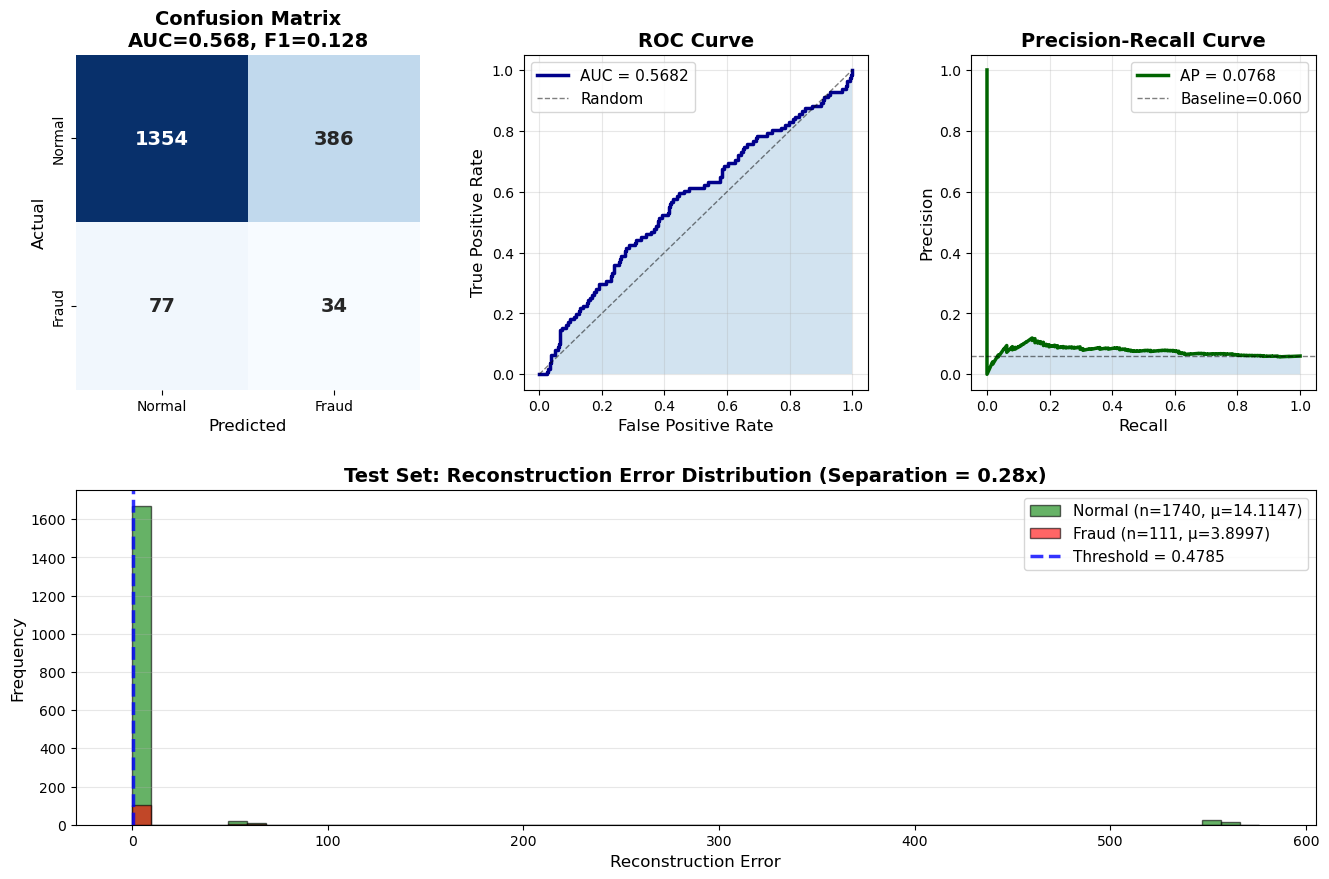

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            ax=ax1, annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_title(f'Confusion Matrix\nAUC={test_auc:.3f}, F1={f1:.3f}', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_xlabel('Predicted', fontsize=12)

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test_np, test_errors)
ax2.plot(fpr, tpr, linewidth=2.5, label=f'AUC = {test_auc:.4f}', color='darkblue')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random', alpha=0.5)
ax2.fill_between(fpr, tpr, alpha=0.2)
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
prec_curve, rec_curve, _ = precision_recall_curve(y_test_np, test_errors)
baseline = y_test_np.mean()
ax3.plot(rec_curve, prec_curve, linewidth=2.5, label=f'AP = {test_ap:.4f}', color='darkgreen')
ax3.axhline(baseline, color='k', linestyle='--', linewidth=1, 
           label=f'Baseline={baseline:.3f}', alpha=0.5)
ax3.fill_between(rec_curve, prec_curve, alpha=0.2)
ax3.set_xlabel('Recall', fontsize=12)
ax3.set_ylabel('Precision', fontsize=12)
ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(alpha=0.3)

# 4. Error Distribution
ax4 = fig.add_subplot(gs[1, :])
max_error = max(test_errors_normal.max(), test_errors_fraud.max())
bins = np.linspace(0, max_error, 60)

ax4.hist(test_errors_normal, bins=bins, alpha=0.6, 
         label=f'Normal (n={len(test_errors_normal)}, μ={test_errors_normal.mean():.4f})', 
         color='green', edgecolor='black')
ax4.hist(test_errors_fraud, bins=bins, alpha=0.6, 
         label=f'Fraud (n={len(test_errors_fraud)}, μ={test_errors_fraud.mean():.4f})', 
         color='red', edgecolor='black')
ax4.axvline(threshold, color='blue', linestyle='--', linewidth=2.5, 
           label=f'Threshold = {threshold:.4f}', alpha=0.8)
ax4.set_xlabel('Reconstruction Error', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title(f'Test Set: Reconstruction Error Distribution (Separation = {separation_ratio:.2f}x)', 
             fontsize=14, fontweight='bold')
ax4.legend(fontsize=11, loc='upper right')
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()